In [80]:
import os, sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from collections import OrderedDict
from torch import nn
from tqdm.auto import tqdm
from scipy.signal import find_peaks

def gait_cycle_generator(peak_indices):
    """
    Generate gait cycles based on detected peaks.
    """
    gc_angle_list = []
    gc_polar_x_list = []
    gc_polar_y_list = []

    for i in range(len(peak_indices) - 1):
        start = peak_indices[i]
        end = peak_indices[i + 1]

        for j in range(start, end):
            gc_polar_angle = (j - start) / (end - start) * 2 * np.pi
            gc_angle_list.append(gc_polar_angle)
            gc_polar_x_list.append(np.cos(gc_polar_angle))
            gc_polar_y_list.append(np.sin(gc_polar_angle))

    # Return as a (N, 2) numpy array for stacking
    return np.column_stack((gc_polar_x_list, gc_polar_y_list))

def polar_to_percentage(polar_coords):
    # Ensure input is a numpy array
    if isinstance(polar_coords, torch.Tensor):
        polar_coords = polar_coords.detach().cpu().numpy()
    angle = np.arctan2(polar_coords[:, 1], polar_coords[:, 0])
    percentage = (angle + 2*np.pi) % (2 * np.pi) / (2 * np.pi) * 100  # Normalize to (0, 100]
    return percentage

# Try importing with the full path
from Model import TCN
from Main import hyperparam_config

def load_model(model_dir, model_name):

    # --- Load the State Dictionary ---
    model_file = os.path.join(model_dir, model_name)
    state_dict = torch.load(model_file, map_location=torch.device('cpu')) # Load to CPU first
    model_instance = TCN(hyperparam_config)
    model_instance.load_state_dict(state_dict)
    # print(f"Loading model from: {model_file}")
    
    return model_instance

def load_input_n_label(file_dir, subject, inclination, speed, model_dir_original):

    imu_file = [file for file in os.listdir(file_dir) if ('imu' in file) and (inclination in file) and (speed in file) and (subject in file)][0]
    motor_file = [file for file in os.listdir(file_dir) if ('motor' in file) and (inclination in file) and (speed in file) and (subject in file)][0]

    input_imu_file = os.path.join(file_dir, imu_file)
    input_motor_file = os.path.join(file_dir, motor_file)

    input_mean = np.load(os.path.join(model_dir_original, 'input_mean.npy'))
    input_std = np.load(os.path.join(model_dir_original, 'input_std.npy'))

    input_imu = pd.read_csv(input_imu_file)
    input_motor = pd.read_csv(input_motor_file)

    input_R_buffer = np.hstack((input_imu[['Thigh_R_Acc_X', 'Thigh_R_Acc_Y', 'Thigh_R_Acc_Z', 'Thigh_R_Gyr_X', 'Thigh_R_Gyr_Y', 'Thigh_R_Gyr_Z']].values,
                            input_motor[['mtr_pos_R']].values))
    input_L_buffer = np.hstack((input_imu[['Thigh_L_Acc_X', 'Thigh_L_Acc_Y', 'Thigh_L_Acc_Z', 'Thigh_L_Gyr_X', 'Thigh_L_Gyr_Y', 'Thigh_L_Gyr_Z']].values,
                            input_motor[['mtr_pos_L']].values))
    input_L_buffer[:, [1, 3, 5]] *= -1 # Mirroring IMU

    peak_indices_R, _ = find_peaks(-input_R_buffer[:,6], height= None, distance=30, prominence=10)
    peak_indices_L, _ = find_peaks(-input_L_buffer[:,6], height= None, distance=30, prominence=10)

    peak_indices_R = np.insert(peak_indices_R, 0,0)
    peak_indices_R = np.insert(peak_indices_R, peak_indices_R.shape[0], input_R_buffer.shape[0])
    peak_indices_L = np.insert(peak_indices_L, 0,0)
    peak_indices_L = np.insert(peak_indices_L, peak_indices_L.shape[0], input_L_buffer.shape[0])

    # Calculate record time based on the length of the input data
    label_R_buffer = gait_cycle_generator(peak_indices_R)
    label_L_buffer = gait_cycle_generator(peak_indices_L)

    # Normalize the input features
    input_R_tensor = torch.tensor((input_R_buffer - input_mean) / input_std, dtype=torch.float32)
    input_L_tensor = torch.tensor((input_L_buffer - input_mean) / input_std, dtype=torch.float32)

    return input_R_buffer, input_L_buffer, input_R_tensor, input_L_tensor, label_R_buffer, label_L_buffer

def get_rmse(all_predictions, label_buffer, window_size):

    # Calculate error metrics
    overlap_length = len(all_predictions)
    ground_truth = label_buffer[window_size-1:window_size-1+overlap_length]
    predictions = all_predictions[:overlap_length]

    error_list = []
    for i in range(overlap_length):
        error = ground_truth[i] - predictions[i]
        if error < -50:
            error_list.append(error + 100)
        elif error > 50:
            error_list.append(error - 100)
        else:
            error_list.append(error)

    rmse = np.sqrt(np.mean((np.array(error_list)) ** 2))

    return rmse

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

def model_evaluation(model_dir_original, model_instance, input_tensor, label_buffer):
    # Move model to device and set to eval mode
    model_instance.to(device)
    model_instance.eval()

    window_size = hyperparam_config['window_size']
    total_length = input_tensor.shape[0]
    valid_predictions_count = total_length - window_size + 1

    # Create array to store all predictions
    all_predictions = np.zeros((valid_predictions_count, hyperparam_config['output_size']))
    # batch_bar = tqdm(total=valid_predictions_count, dynamic_ncols=True, position=0, leave=False, desc='Processing windows', unit='window')

    label_mean = np.load(os.path.join(model_dir_original, 'label_mean.npy'))
    label_std = np.load(os.path.join(model_dir_original, 'label_std.npy'))
    batch_size = 4096  # You can adjust this value based on your GPU memory

    with torch.no_grad():
        # Process Right side in batches
        for start_idx in tqdm(range(0, valid_predictions_count, batch_size), desc='Processing windows', dynamic_ncols=True, position=0, leave=False, unit='window'):
            end_idx = min(start_idx + batch_size, valid_predictions_count)
            batch_windows = []
            for i in range(start_idx, end_idx):
                window = input_tensor[i:i+window_size, :].unsqueeze(0)
                batch_windows.append(window)
            batch_windows = torch.cat(batch_windows, dim=0).transpose(1, 2).to(device)
            pred_normalized = model_instance(batch_windows)
            pred_value = (pred_normalized.cpu().numpy() * label_std) + label_mean
            all_predictions[start_idx:end_idx] = pred_value

    # Create appropriate time axis for predictions
    pred_time_axis = np.arange(window_size-1, window_size-1+valid_predictions_count) / 100  # Assuming 100Hz
    time_axis = np.arange(0, len(label_buffer)) / 100  # Assuming 100Hz sampling rate

    predictions_perc = polar_to_percentage(all_predictions)
    gt_perc = polar_to_percentage(label_buffer)

    return get_rmse(predictions_perc, gt_perc, window_size)

cuda


In [81]:
TCN_frozen_state = 'tcn_frozen'
incline_conditions = ['RD_10deg', 'RD_5deg', 'LG', 'RA_5deg', 'RA_10deg']
speed_conditions = ['0p4mps', '0p5mps', '0p6mps', '0p7mps', '0p8mps', '0p9mps', '1p0mps']
gait_cycle_all = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
subjects = ['PT01_Cole_hemiplegic', 'PT02_Ilseung_hemiplegic', 'PT03_Changseob_hemiplegic']

model_dir_original = '/home/metamobility5/Changseob/proj-online_adaptation_GPE/training_results/hyperparam_optimized-input_modality_7'
file_dir = f'/home/metamobility5/Changseob/proj-online_adaptation_GPE/subject_data/0928_hemiplegic_offline-speed_segmented/'

rmse_averaged = {inc: {spd: {gc: None for gc in gait_cycle_all} for spd in speed_conditions} for inc in incline_conditions}

for incline in incline_conditions:
    for speed in speed_conditions:
        if (incline == 'RD_10deg') and ((speed == '0p4mps') or (speed == '0p5mps')): continue
        print(f'Loading data from {incline}, {speed}')

        for gait_cycle in gait_cycle_all:
            rmse_subjects = []

            for subject in subjects:
                model_dir = f'/home/metamobility5/Changseob/proj-online_adaptation_GPE/effect_of_freezing_tcn/{TCN_frozen_state}-FIFO_buffer_interpolated/{subject}'
                model_names = sorted([f for f in os.listdir(model_dir) if f.endswith('.pt')], key=lambda f: os.path.getmtime(os.path.join(model_dir, f)))
                model_instance = load_model(model_dir, model_names[int(gait_cycle/2)])
                
                input_R_buffer, input_L_buffer, input_R_tensor, input_L_tensor, label_R_buffer, label_L_buffer\
                    = load_input_n_label(file_dir, subject, incline, speed, model_dir_original)
                
                rmse_subjects.append(model_evaluation(model_dir_original, model_instance, input_R_tensor, label_R_buffer))

            rmse_averaged[incline][speed][gait_cycle] = np.mean(rmse_subjects)
            print('\t', rmse_averaged[incline][speed][gait_cycle])


Loading data from RD_10deg, 0p6mps


Processing windows:   0%|          | 0/1 [00:00<?, ?window/s]

Processing windows:   0%|          | 0/1 [00:00<?, ?window/s]

Processing windows:   0%|          | 0/1 [00:00<?, ?window/s]

	 6.556307940777089


...

	 6.0458731565480806


Processing windows:   0%|          | 0/1 [00:00<?, ?window/s]

Processing windows:   0%|          | 0/1 [00:00<?, ?window/s]

Processing windows:   0%|          | 0/1 [00:00<?, ?window/s]

	 6.029494281642965


/tmp/ipykernel_2469231/1506519309.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('copper', len(speed_conditions))  # You can choose other colormaps like 'jet', 'plasma', etc.


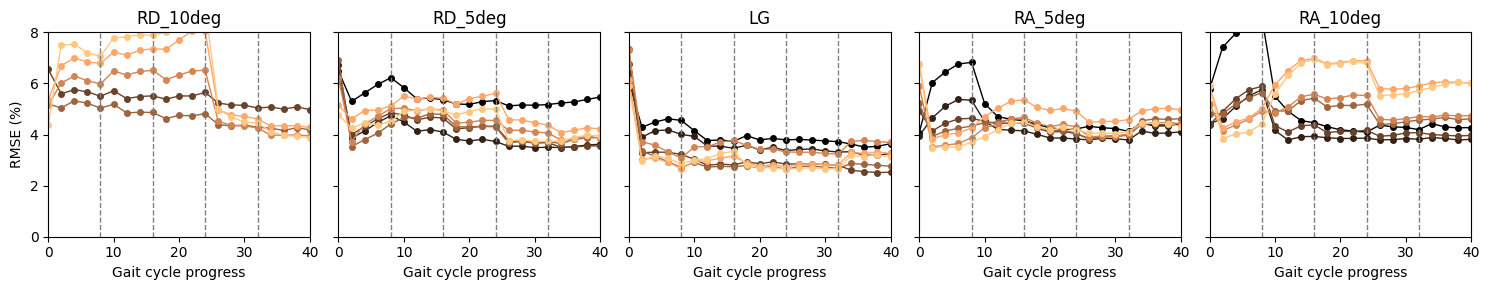

In [82]:
import matplotlib.cm as cm
colormap = cm.get_cmap('copper', len(speed_conditions))  # You can choose other colormaps like 'jet', 'plasma', etc.
speed_colors = {speed_conditions[i]: colormap(i) for i in range(len(speed_conditions))}

fig, axes = plt.subplots(1, len(incline_conditions), figsize=(15, 3), sharey=True)

for i, incline in enumerate(incline_conditions):
        ax = axes[i]
        for speed in speed_conditions:
            if (incline == 'RD_10deg') and ((speed == '0p4mps') or (speed == '0p5mps')): continue
        #     if (incline == 'LG') and (speed == '0p7mps'): continue
            ax.plot(gait_cycle_all, list(rmse_averaged[incline][speed].values()), marker='o', label=speed, color=speed_colors[speed], markersize=4, linewidth=1)

        ax.set_xlabel('Gait cycle progress')
        if i == 0:
                ax.set_ylabel('RMSE (%)')
        ax.set_title(f'{incline}')
        # ax.set_xticks(gait_cycle_all)
        ax.set_xlim(0, 40)
        ax.set_ylim(0, 8)
        for xc in [8, 16, 24, 32]:
            ax.axvline(x=xc, color = 'grey', linewidth = 1, linestyle = '--')

# ax.legend(fontsize='small')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

# Save the dictionary to a pickle file
with open('rmse_averaged-frozen.pkl', 'wb') as f:
    pickle.dump(rmse_averaged, f)

In [ ]:
with open('rmse_averaged-unfrozen_high_lr.pkl', 'rb') as f:
    rmse_averaged = pickle.load(f)

In [ ]:
import pickle

total_dict = [None] * 5
# Load the dictionary from the pickle file
with open('rmse_averaged-unfrozen_high_lr.pkl', 'rb') as f:
    total_dict[0] = pickle.load(f)
with open('rmse_averaged-unfrozen.pkl', 'rb') as f:
    total_dict[1] = pickle.load(f)
with open('rmse_averaged-frozen.pkl', 'rb') as f:
    total_dict[2] = pickle.load(f)
with open('rmse_averaged-frozen_replay_buffer.pkl', 'rb') as f:
    total_dict[3] = pickle.load(f)
with open('rmse_averaged-frozen_replay_buffer_interpolated.pkl', 'rb') as f:
    total_dict[4] = pickle.load(f)

xtick = ['unfrozen (high lr)', 'unfrozen', 'frozen', 'frozen (replay buffer)', 'frozen (interpolated replay buffer)']

import matplotlib.cm as cm
colormap = cm.get_cmap('copper', len(speed_conditions))  # You can choose other colormaps like 'jet', 'plasma', etc.
speed_colors = {speed_conditions[i]: colormap(i) for i in range(len(speed_conditions))}

fig, axes = plt.subplots(1, len(incline_conditions)+1, figsize=(15, 4.5), sharey=True)

for i, incline in enumerate(incline_conditions):
    ax = axes[i]

    for speed in speed_conditions:
        if (incline == 'RD_10deg') and ((speed == '0p4mps') or (speed == '0p5mps')): continue
        if (incline == 'LG') and (speed == '0p7mps'): continue
        # Prepare data for plotting.  Each entry in total_dict contains the same keys, so we can access them safely.
        rmse_values = [total_dict[j][incline][speed][12] for j in range(len(total_dict))]
        # Reshape the data so that each row corresponds to a gait cycle
        # Plot
        ax.plot(range(len(xtick)), rmse_values, marker='o', label=speed, color=speed_colors[speed], markersize=4, linewidth=1)
    ax.set_xticklabels(xtick, rotation=45, ha='right')
    ax.set_xticks(range(len(xtick)))

    if i == 0:
        ax.set_ylabel('RMSE (%)')
    ax.set_title(f'{incline}')
    # ax.set_xticks(gait_cycle_all)
    ax.set_xlim(0, len(xtick)-1)
    ax.set_ylim(0, 10)

ax = axes[len(incline_conditions)]
    
all_rmse_values = []
for j in range(len(total_dict)):
    temp_rmse_values = []
    for incline in incline_conditions:
        for speed in speed_conditions:
            if (incline == 'RD_10deg') and ((speed == '0p4mps') or (speed == '0p5mps')): continue
            if (incline == 'LG') and (speed == '0p7mps'): continue
            temp_rmse_values.append(total_dict[j][incline][speed][12])  # Access the 12th gait cycle
    print(j, temp_rmse_values)
    all_rmse_values.append(np.mean(temp_rmse_values))
    
ax.plot(range(len(xtick)), [all_rmse_values[j] for j in range(len(total_dict))], marker='o', markersize=4, linewidth=1)
ax.set_xticklabels(xtick, rotation=45, ha='right')
ax.set_xticks(range(len(xtick)))
ax.set_title('Average')
ax.set_xlim(0, len(xtick)-1)
ax.set_ylim(0, 10)

# ax.legend(fontsize='small')
plt.tight_layout()
plt.show()